====== TASK B: CHI-SQUARE TEST OF INDEPENDENCE TOOLKIT ======

--- 1. Assumption Checks ---
Minimum expected frequency in any cell: 20.00
-> Pass: All expected cell counts are >= 5. The Chi-Square approximation is valid.



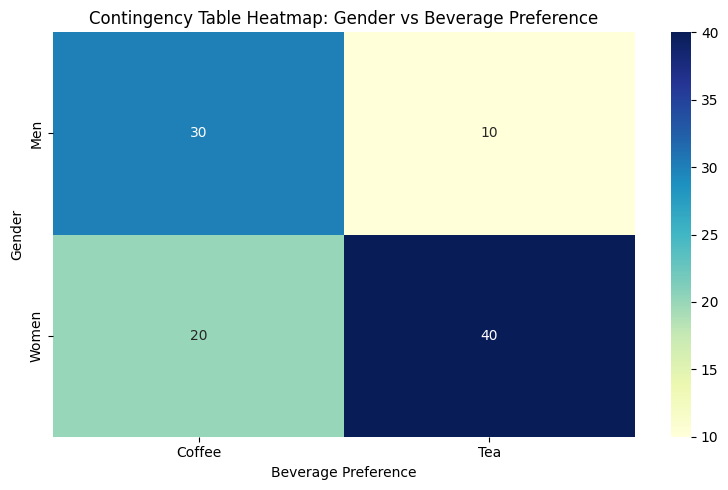


--- 2. Test Results Table ---
                      Metric                                                    Value
        Null Hypothesis (H0)          Gender and Beverage Preference are independent.
 Alternative Hypothesis (Ha) Gender and Beverage Preference are dependent/associated.
             Sample Size (N)                                                  N = 100
Sample Mean(s) / Proportions                 See cross-tabulation visual distribution
             Mean Difference                                      N/A for Categorical
       Test Statistic (Chi2)                                                  15.0417
          Degrees of Freedom                                                        1
                     p-value                                               1.0516e-04
      Significance Level (α)                                                     0.05
                    Decision                                                Reject H0

----------------------

In [3]:

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
def chi_square_toolkit(data_matrix, row_labels, col_labels, var1_name="Variable 1", var2_name="Variable 2", alpha=0.05):
    print("====== TASK B: CHI-SQUARE TEST OF INDEPENDENCE TOOLKIT ======\n")
    
    # Convert input data to a structured DataFrame contingency table
    contingency_table = pd.DataFrame(data_matrix, index=row_labels, columns=col_labels)
    
    # 2. Run Test to get expected frequencies first for assumption checking
    chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)
    
    # 1. Assumption Checks
    print("--- 1. Assumption Checks ---")
    min_expected = np.min(expected)
    print(f"Minimum expected frequency in any cell: {min_expected:.2f}")
    if min_expected >= 5:
        print("-> Pass: All expected cell counts are >= 5. The Chi-Square approximation is valid.")
    else:
        print("-> Warning: Some expected cell counts are less than 5. Consider using Fisher's Exact test or grouping categories.")
    print()

    # 2. Data Visualization
    plt.figure(figsize=(8, 5))
    sns.heatmap(contingency_table, annot=True, fmt="d", cmap="YlGnBu", cbar=True)
    plt.title(f"Contingency Table Heatmap: {var1_name} vs {var2_name}")
    plt.ylabel(var1_name)
    plt.xlabel(var2_name)
    plt.tight_layout()
    plt.show()

    decision = "Reject H0" if p_val < alpha else "Fail to Reject H0"

    # 3. Summary Table
    results_data = {
        "Metric": [
            "Null Hypothesis (H0)", "Alternative Hypothesis (Ha)", 
            "Sample Size (N)", "Sample Mean(s) / Proportions", "Mean Difference", 
            "Test Statistic (Chi2)", "Degrees of Freedom", "p-value", "Significance Level (α)", "Decision"
        ],
        "Value": [
            f"{var1_name} and {var2_name} are independent.", f"{var1_name} and {var2_name} are dependent/associated.",
            f"N = {np.sum(data_matrix)}", "See cross-tabulation visual distribution", "N/A for Categorical",
            f"{chi2:.4f}", f"{dof}", f"{p_val:.4e}", f"{alpha}", decision
        ]
    }
    df_results = pd.DataFrame(results_data)
    
    print("\n--- 2. Test Results Table ---")
    print(df_results.to_string(index=False))
    print("\n" + "-"*50)
    
    # 4. Automatically Generated Conclusion Paragraph
    print("\n--- 3. Conclusion Paragraph ---")
    if p_val < alpha:
        conclusion = (
            f"Based on the Chi-Square Test of Independence, we reject the null hypothesis at a significance level of α = {alpha} "
            f"(χ²({dof}) = {chi2:.4f}, p = {p_val:.4e}). The data provides strong empirical evidence that a statistically significant "
            f"association exists between {var1_name} and {var2_name}. The distribution of categories indicates that these variables "
            f"do not vary independently of each other."
        )
    else:
        conclusion = (
            f"Based on the Chi-Square Test of Independence, we fail to reject the null hypothesis at a significance level of α = {alpha} "
            f"(χ²({dof}) = {chi2:.4f}, p = {p_val:.4f}). There is insufficient evidence to conclude that {var1_name} and {var2_name} "
            f"are associated. Any apparent patterns or imbalances within the observed contingency table can be reasonably attributed "
            f"to random variations in sampling."
        )
    print(conclusion)
    print("\n" + "="*50)

# --- Example Usage for Testing Task B ---
# Imagine testing if Preferring Coffee vs Tea is dependent on Gender
toy_data = [
    [30, 10],  # Men: [Coffee, Tea]
    [20, 40]   # Women: [Coffee, Tea]
]
chi_square_toolkit(
    data_matrix=toy_data, 
    row_labels=["Men", "Women"], 
    col_labels=["Coffee", "Tea"],
    var1_name="Gender",
    var2_name="Beverage Preference"
)